**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 05. Spatial Extremes
Spatial extremes analysis extends classical univariate extreme value theory to multiple locations, enabling regional flood frequency analysis with rigorous uncertainty quantification. This chapter provides a comprehensive introduction to spatial GEV modeling using Bayesian Hierarchical Models (BHM), suitable for readers with foundational knowledge of probability and statistics but limited exposure to spatial statistics or extreme value theory.

## What You'll Learn
- Spatial regression
- Spatial correlation
- Gaussian Copula
- Bayesian hierarchical modeling
- Estimating 100 and 500 year floods

## Set Up

In [ ]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

from RMC.BestFit.Models.TrendFunctions import GeneralLinearFunction
from RMC.BestFit.Models.SpatialExtremes import SpatialGEV, SpatialRegressionErrors, BasicExponential, PoweredExponential, Spherical, CorrelationFunctionType, GaussianCopula
from RMC.BestFit.Analyses import SpatialGEVAnalysis

from Numerics.Distributions import GeneralizedExtremeValue

from System import Array, Double, Random

print("✓ Imported namespaces successfully")

## Spatial Regression on GEV Parameters

### Link Functions

GEV parameters have natural constraints that require appropriate link functions:
- **Location ($\xi$)**: Often positive for flood data, so log-link ensures positivity
- **Scale ($\alpha$)**: Must be positive, so log-link is essential
- **Shape ($\kappa$)**: Typically small ($|\kappa| < 0.5$), so identity link with bounded priors

### Location Parameter

With log-link:

```math
\log(\xi_j) = \beta_0^\xi + \beta_1^\xi X_{1j} + \beta_2^\xi X_{2j} + \cdots + \beta_K^\xi X_{Kj}
```

Equivalently:

```math
\xi_j = \exp\left(\beta_0^\xi + \sum_{k=1}^K \beta_k^\xi X_{kj}\right)
```

**Interpretation**: Regression coefficients represent multiplicative effects. A unit increase in covariate $X_k$ multiplies location by $\exp(\beta_k^\xi)$.

### Scale Parameter

With log-link:

```math
\log(\alpha_j) = \beta_0^\alpha + \sum_{k=1}^K \beta_k^\alpha X_{kj}
```

This ensures $\alpha_j > 0$ for all covariate values.

### Shape Parameter

With identity link:

```math
\kappa_j = \beta_0^\kappa + \sum_{k=1}^K \beta_k^\kappa X_{kj}
```

Shape is kept near zero through bounded priors, typically $|\kappa_j| < 0.5$.

### Common Covariates

For spatial flood frequency analysis, useful covariates include:

| Covariate | Symbol | Effect on Floods |
|-----------|--------|------------------|
| Longitude | $X$ | East-west climate gradients |
| Latitude | $Y$ | North-south climate gradients |
| Elevation | $Z$ | Orographic precipitation effects |
| Drainage area | $A$ | Larger basins → larger floods |
| Mean precipitation | $P$ | Wetter regions → larger floods |
| Basin slope | $S$ | Steeper basins → faster concentration |


In [18]:
def create_test_site_data():

    data = Array.CreateInstance(Double, 30, 5)

    rng = Random(12345)
    gev = GeneralizedExtremeValue(10000.0, 2500.0, 0.0)

    for site in range(5):
        for year in range(30):
            data[year,site] = gev.InverseCDF(rng.NextDouble())

    return data

coordinate_values = [
    [0.0, 0.0],
    [10.0, 5.0],
    [22.0, 8.0],
    [35.0, 12.0],
    [50.0, 15.0]
]

test_coordinates = Array.CreateInstance(Double, 5, 2)

for i in range(5):
    for j in range(2):
        test_coordinates[i, j] = coordinate_values[i][j]

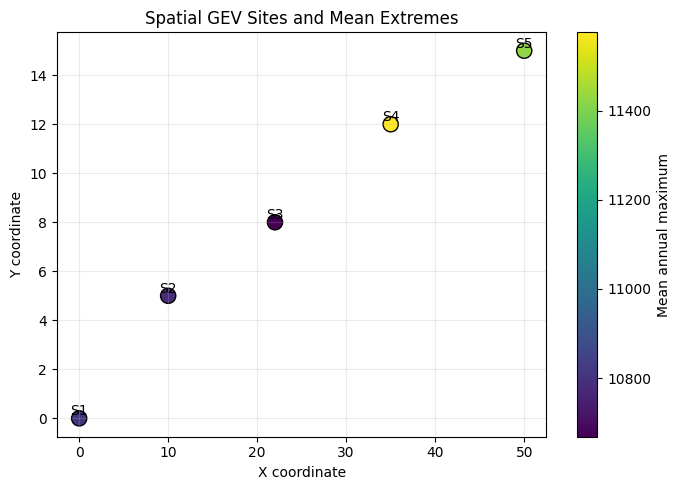

In [19]:
# Prepare site data (n_obs x n_sites matrix)
data =  create_test_site_data()

# Plot the spatial sites and each site's sample mean annual maximum.
coords = np.array([[float(test_coordinates[i, 0]), float(test_coordinates[i, 1])] for i in range(test_coordinates.GetLength(0))])
site_means = np.array([
    np.mean([float(data[row, col]) for row in range(data.GetLength(0))])
    for col in range(data.GetLength(1))
])
plt.figure(figsize=(7, 5))
points = plt.scatter(coords[:, 0], coords[:, 1], c=site_means, s=120, cmap="viridis", edgecolor="black")
for i, (x_coord, y_coord) in enumerate(coords, start=1):
    plt.text(x_coord, y_coord, f"S{i}", ha="center", va="bottom")
plt.colorbar(points, label="Mean annual maximum")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Spatial GEV Sites and Mean Extremes")
plt.grid(alpha=0.25)
plt.tight_layout()

# Create covariate matrix (X and Y coordinates)
n_sites = test_coordinates.GetLength(0)
covariates = Array.CreateInstance(Double, n_sites, 2)
for j in range(n_sites):
    covariates[j, 0] = test_coordinates[j, 0] # X
    covariates[j, 1] = test_coordinates[j, 1] # Y

# Create GeneralLinearFunction for each parameter
location = GeneralLinearFunction("Location", covariates)
scale = GeneralLinearFunction("Scale", covariates)
shape = GeneralLinearFunction("Shape") # Intercept only

# Create spatial GEV model
model = SpatialGEV(data, test_coordinates, location, scale, shape)
model.UseLogLinkForLocation = True
model.UseLogLinkForScale = True

Empirical correlation between sites' annual extremes, generated from the simulated dataset. This gives a visual check before fitting the spatial GEV model.

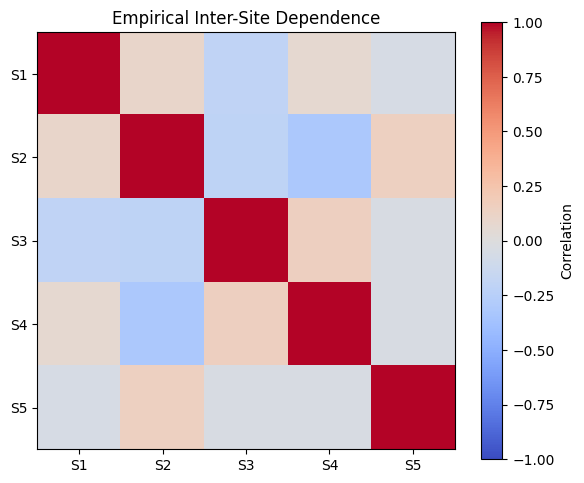

In [20]:
# Empirical site-to-site correlation matrix from generated annual extremes
site_values = np.array([[float(data[row, col]) for col in range(data.GetLength(1))] for row in range(data.GetLength(0))])
corr = np.corrcoef(site_values, rowvar=False)
plt.figure(figsize=(6, 5))
plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(corr.shape[0]), [f"S{i+1}" for i in range(corr.shape[0])])
plt.yticks(range(corr.shape[0]), [f"S{i+1}" for i in range(corr.shape[0])])
plt.title("Empirical Inter-Site Dependence")
plt.tight_layout()


## Spatial Correlation Structures

Spatial correlation functions describe how similarity between locations decreases with distance. Let $h = \|\mathbf{s}_i - \mathbf{s}_j\|$ denote the Euclidean distance between sites $i$ and $j$. The correlation function $\rho(h)$ must satisfy:
- $\rho(0) = 1$ (perfect correlation at zero distance)
- $0 \leq \rho(h) \leq 1$ for all $h \geq 0$
- $\rho(h) \to 0$ as $h \to \infty$ (decay to independence)
- Positive definiteness (required for valid covariance matrices)

### Basic Exponential

```math
\rho(h) = \exp\left(-\frac{h}{r}\right)
```

where $r > 0$ is the **range** (or **scale**) parameter.

**Properties**:
- Exponential decay with distance
- Practical range (correlation drops to 0.05): approximately $3r$
- Infinitely divisible (valid for any positive definite operation)
- Non-differentiable at the origin (rough process realizations)

**When to use**: Default choice; robust and widely applicable.

### Powered Exponential

```math
\rho(h) = \exp\left(-\left(\frac{h}{r}\right)^p\right)
```

where $r > 0$ is the range and $0 < p \leq 2$ is the **power** parameter.

**Special cases**:
- $p = 1$: Basic exponential
- $p = 2$: Gaussian (squared exponential)

**Properties**:
- Higher $p$ gives smoother correlation decay
- Gaussian ($p = 2$) produces infinitely differentiable (smooth) process realizations
- Practical range varies with $p$

**When to use**: When process smoothness is important; $p \approx 1.5$ often works well.

### Spherical

```math
\rho(h) = \begin{cases}
1 - \frac{3h}{2r} + \frac{h^3}{2r^3} & \text{if } h < r \\
0 & \text{if } h \geq r
\end{cases}
```

**Properties**:
- **Compact support**: Exactly zero correlation beyond range $r$
- Computational advantage for large networks (sparse correlation matrices)
- Transition from correlation to independence at distance $r$

**When to use**: When distant sites are believed truly independent; reduces computational burden.

### Comparison

| Property | Basic Exponential | Powered Exponential | Spherical |
|----------|-------------------|---------------------|-----------|
| Parameters | 1 (range) | 2 (range, power) | 1 (range) |
| Smoothness | Rough | Adjustable | Moderate |
| Compact support | No | No | Yes |
| Computation | O(S²) | O(S²) | O(S² sparse) |

### Evaluating Correlation Functions
Each correlation function takes a `Range` (and, for the powered exponential, a `Power`) and returns the correlation at a given separation distancce. Below we evaluated each function at a distance of 9 units to compare how quickly they decay.

Basic exponential @ d=9: 0.4065696597405991
Powered exponential @ d=9: 0.42578746389901556
Spherical @ d=9: 0.014499999999999957


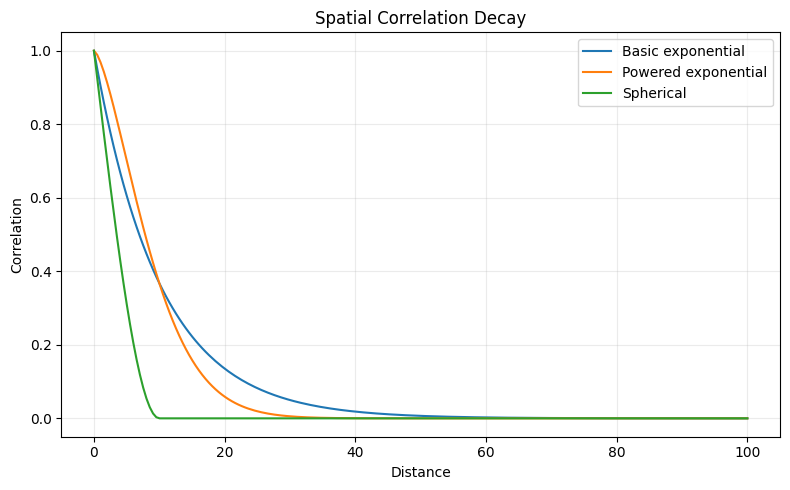

In [21]:
# ADD EXPLANATION ABT WHAT THESE MEAN

basic_exp = BasicExponential()
basic_exp.Range = 30
print("Basic exponential @ d=9:", basic_exp.Evaluate(9))

power_exp = PoweredExponential()
power_exp.Range = 30
power_exp.Power = 1.5
print("Powered exponential @ d=9:", power_exp.Evaluate(9))

spherical = Spherical()
spherical.Range = 50 
print("Spherical @ d=9:", spherical.Evaluate(9))

# Spatial correlation decay by distance
x = np.linspace(0,100,200)
plt.figure(figsize=(8,5))
for name, fn in {"Basic exponential": basic_exp, "Powered exponential": power_exp, "Spherical": spherical}.items():
    plt.plot(x, [fn.Evaluate(float(d)) for d in x], label=name)
plt.xlabel("Distance"); plt.ylabel("Correlation"); plt.title("Spatial Correlation Decay"); plt.grid(alpha=.25); plt.legend(); plt.tight_layout()

When can then use our understanding of these correlation structures to define error terms in our model.

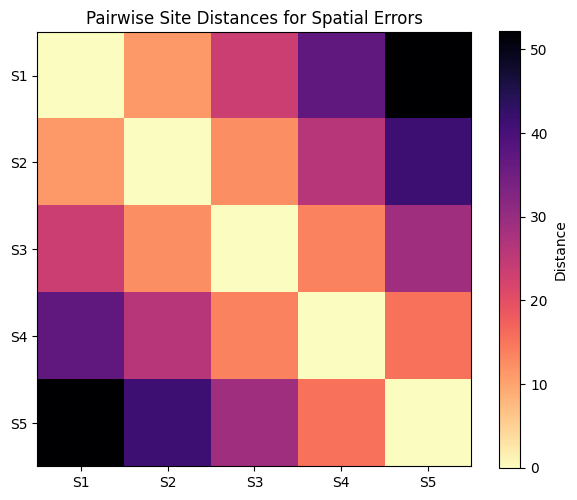

In [ ]:
# Create spatial error model
loc_errors = SpatialRegressionErrors(test_coordinates, CorrelationFunctionType.Exponential) # IMPLEMENTED DIFFERENTLY IN BESTFIT DOCS
scl_errors = SpatialRegressionErrors(test_coordinates, CorrelationFunctionType.Exponential) # # IMPLEMENTED DIFFERENTLY IN BESTFIT DOCS

# Enable spatial errors
model.UseLocationErrors = True
model.LocationErrors = loc_errors
model.UseScaleErrors = True
model.ScaleErrors = scl_errors

model.SetDefaultParameters()

# !!! Use BestFit results not python? !!!
# Plot pairwise site distances that drive the spatial regression error structure.
coords = np.array([[float(test_coordinates[i, 0]), float(test_coordinates[i, 1])] for i in range(test_coordinates.GetLength(0))])
distance_matrix = np.zeros((len(coords), len(coords)))
for i in range(len(coords)):
    for j in range(len(coords)):
        distance_matrix[i, j] = np.sqrt(np.sum((coords[i] - coords[j]) ** 2))
plt.figure(figsize=(6, 5))
plt.imshow(distance_matrix, cmap="magma_r")
plt.colorbar(label="Distance")
plt.xticks(range(len(coords)), [f"S{i+1}" for i in range(len(coords))])
plt.yticks(range(len(coords)), [f"S{i+1}" for i in range(len(coords))])
plt.title("Pairwise Site Distances for Spatial Errors")
plt.tight_layout()

## Gaussian Coupula for Inter-Site Dependence
When analyzing regional extremes, observations at different sites in the same year are typically not independent—a major storm produces large floods at multiple nearby stations. A **copula** models this dependence structure separately from the marginal distributions [[5]](#5).

**Sklar's Theorem**: Any multivariate distribution can be decomposed as:

```math
F(y_1, \ldots, y_S) = C(F_1(y_1), \ldots, F_S(y_S))
```

where $F_j$ are the marginal CDFs and $C: [0,1]^S \to [0,1]$ is the copula function capturing dependence.

### The Gaussian Copula

The Gaussian copula is defined through the multivariate normal distribution:

```math
C(u_1, \ldots, u_S) = \Phi_{\mathbf{R}}(\Phi^{-1}(u_1), \ldots, \Phi^{-1}(u_S))
```

where:
- $\Phi$ is the standard normal CDF
- $\Phi^{-1}$ is the standard normal quantile function
- $\Phi_{\mathbf{R}}$ is the CDF of the multivariate normal with correlation matrix $\mathbf{R}$


### Why Gaussian Copula?

**Advantages**:
1. Mathematically tractable (closed-form density)
2. Flexible range of dependence (correlation matrix)
3. Natural spatial interpretation (correlation decays with distance)
4. Efficient computation via Cholesky decomposition

**Limitations**:
1. Symmetric dependence (cannot model asymmetric tail dependence)
2. Tail independence (joint extremes less likely than heavy-tailed copulas)
3. May underestimate joint flood risk at very high return periods

For flood frequency analysis, the Gaussian copula is typically adequate because:
- Annual maxima from different sites have moderate dependence
- Primary interest is in marginal quantiles, not joint exceedance probabilities
- More complex copulas (e.g., extreme-value copulas) add parameters without clear practical benefit

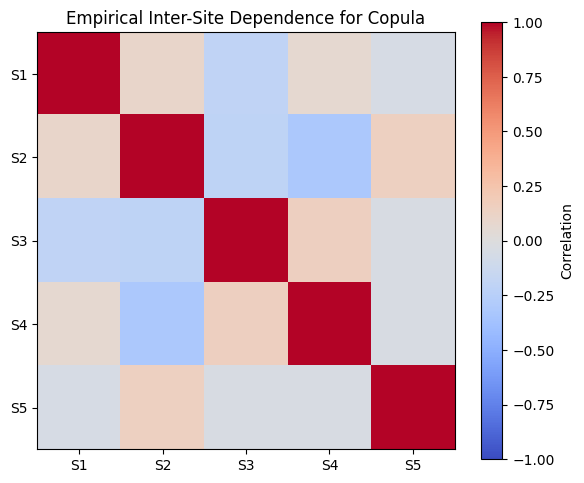

In [23]:
# Create Gaussian copula with exponential correlation
copula = GaussianCopula(test_coordinates, CorrelationFunctionType.Exponential)

model.UseCopulaDependence = True
model.SpatialDependence = copula

model.SetDefaultParameters()

# !!! Use BestFit results not python !!!
# Plot empirical same-year dependence across sites for the copula model context.
site_values = np.array([[float(data[row, col]) for col in range(data.GetLength(1))] for row in range(data.GetLength(0))])
corr = np.corrcoef(site_values, rowvar=False)
plt.figure(figsize=(6, 5))
plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(corr.shape[0]), [f"S{i+1}" for i in range(corr.shape[0])])
plt.yticks(range(corr.shape[0]), [f"S{i+1}" for i in range(corr.shape[0])])
plt.title("Empirical Inter-Site Dependence for Copula")
plt.tight_layout()

In the code below we seek to estimate the 100-year and 500-year flood at each site. These are quantiles of the fitted GEV distribution, where the $p$-quantile (value exceeded with probability $1-p$) is:

```math
x_p = \xi + \frac{\alpha}{\kappa}\left[(-\log p)^{-\kappa} - 1\right]
```

For the Gumbel case ($\kappa = 0$):

```math
x_p = \xi - \alpha \log(-\log p)
```

The 100-year flood corresponds to $p = 0.99$ (or equivalently, 1% annual exceedance probability). The 500-year flood corresponds to 

In [24]:
def return_level(site_result, T):
    target_p = 1.0 / T

    idx = min(
        range(len(site_result.Probabilities)),
        key=lambda i: abs(site_result.Probabilities[i] - target_p)
    )

    return site_result.QuantileMean[idx]

## Bayesian Hierarchical Model
The spatial GEV model follows the hierarchical framework developed by Renard et al. [[3]](#3), [[4]](#4), consisting of three levels:

### Level 1: Data Model

At each site $j \in \{1, \ldots, S\}$ with $n_j$ observations:

```math
Y_{ij} \mid \theta_j \sim \text{GEV}(\xi_j, \alpha_j, \kappa_j), \quad i = 1, \ldots, n_j
```

where $\theta_j = (\xi_j, \alpha_j, \kappa_j)$ are the site-specific GEV parameters.

**Spatial Dependence**: Within a given year, observations across sites may be correlated (e.g., a regional storm produces high flows at multiple stations simultaneously). This dependence is captured through a Gaussian copula (see Gaussian section above).

### Level 2: Process Model

GEV parameters at each site are functions of:
1. **Spatial regression**: Linear functions of covariates (location, elevation, drainage area, etc.)
2. **Spatially correlated errors**: Gaussian process deviations from the regression surface

For the location parameter with log-link:

```math
\log(\xi_j) = \beta_0^\xi + \beta_1^\xi X_{1j} + \beta_2^\xi X_{2j} + \varepsilon_j^\xi
```

where:
- $\beta_0^\xi$ is the intercept
- $\beta_k^\xi$ are regression coefficients
- $X_{kj}$ are covariate values at site $j$ (e.g., latitude, longitude, elevation)
- $\varepsilon_j^\xi$ is a spatially correlated error term

The vector of errors $\boldsymbol{\varepsilon}^\xi = (\varepsilon_1^\xi, \ldots, \varepsilon_S^\xi)$ follows:

```math
\boldsymbol{\varepsilon}^\xi \sim \mathcal{N}(\mathbf{0}, \sigma_\xi^2 \mathbf{R}_\xi)
```

where $\mathbf{R}_\xi$ is a correlation matrix determined by a spatial correlation function.

### Level 3: Prior Model

Hyperparameters (regression coefficients, error variance, correlation parameters) receive prior distributions:

```math
\begin{aligned}
\beta_k^\xi &\sim \text{Uniform}(L_\beta, U_\beta) \\
\sigma_\xi &\sim \text{Uniform}(0, U_\sigma) \text{ or Jeffreys prior} \\
\text{range} &\sim \text{Uniform}(0, U_r)
\end{aligned}
```

**Note:** The final model below is rebuilt from scratch for the full Bayesian run and does not carry over the `UseLocationErrors`/`UseScaleErrors`/`UseCouplaDependence` settings configured in the earlier demo cells. If you want those spatial error/copula settings included in the Bayesian analysis, re-apply them to `model` before constructing `SpatialGEVAnalysis`.

In [25]:
model = SpatialGEV(data, test_coordinates, location, scale, shape)
model.UseLogLinkForLocation = True
model.UseLogLinkFotScale = True

analysis = SpatialGEVAnalysis(model)

# Configure MCMC
analysis.BayesianAnalysis.Iterations = 20000
analysis.BayesianAnalysis.WarmupIterations = 10000
analysis.BayesianAnalysis.ThinningInterval = 10
analysis.BayesianAnalysis.NumberOfChains = 4

# Run analysis
analysis.RunAsync().Wait()

# Access MAP estimate
map = analysis.BayesianAnalysis.Results.MAP.Values

# Posterior means
posterior_mean = [
    p.SummaryStatistics.Mean
    for p in analysis.BayesianAnalysis.Results.ParameterResults
]
analysis.SiteResults

# Site-specific results
for site_result in analysis.SiteResults:
    print(f"Site Index: {site_result.SiteIndex}")
    print(f"  100-year flood: {return_level(site_result, 100):.3f}") # BESTFIT DOCS STRAY OFF COURSE HERE
    print(f"  500-year flood: {return_level(site_result, 500):.3f}")

Site Index: 0
  100-year flood: 18009.783
  500-year flood: 20371.759
Site Index: 1
  100-year flood: 18620.567
  500-year flood: 21141.338
Site Index: 2
  100-year flood: 19269.578
  500-year flood: 21933.813
Site Index: 3
  100-year flood: 20104.169
  500-year flood: 22964.011
Site Index: 4
  100-year flood: 21074.078
  500-year flood: 24145.840


## Summary 
In this notebook you:       
$\checkmark$ Explored regression-based location and scale parameters        
$\checkmark$ Calculated inter-site dependence with spatial correlation functions        
$\checkmark$ Calculated inter-site dependence with a Gaussian copula        
$\checkmark$ Ran a Bayesian hierarchical model      
$\checkmark$ Estimated site-specific 100 and 500 year flood return levels       

## Exercises
1. Add covariates (elevation, area) to `GeneralLinearFunction` instead of intercept-only
2. Compare return-level estimates with and without `UseCopulaDependence` enabled